In [5]:
!pip install pyspark

In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("IndiaSmartEnergyAnalytics") \
    .getOrCreate()

raw_df = spark.read.csv("/content/Indias_Electricity_Consumption_Dataset.csv", header=True, inferSchema=True)

from pyspark.sql.functions import rand, round as spark_round
weather_df = raw_df.select("Dates").withColumn("Temperature", spark_round((rand() * 20) + 15, 1))

print("Indian Energy Dataset loaded successfully!")
raw_df.show(5)

Indian Energy Dataset loaded successfully!
+---+----------+--------------+-----------------+-----+-----+----------+------------+---+-----+----+----+-----------+---+-------+-------+----+----+---------+---------+------+-----------+-------+---------+-------+-----+--------+------+-----+------+---------+------+----------+---------+-------+-----+-----------+-----------+------------------+
|_c0|     Dates|Andhra Pradesh|Arunachal Pradesh|Assam|Bihar|Chandigarh|Chhattisgarh| DD|Delhi| DNH| DVC|Essar steel|Goa|Gujarat|Haryana|  HP| J&K|Jharkhand|Karnataka|Kerala|Maharashtra|Manipur|Meghalaya|Mizoram|   MP|Nagaland|Odisha|Pondy|Punjab|Rajasthan|Sikkim|Tamil Nadu|Telangana|Tripura|   UP|Uttarakhand|West Bengal| Total Consumption|
+---+----------+--------------+-----------------+-----+-----+----------+------------+---+-----+----+----+-----------+---+-------+-------+----+----+---------+---------+------+-----------+-------+---------+-------+-----+--------+------+-----+------+---------+------+-------

In [7]:
energy_rdd = raw_df.rdd

mapped_rdd = energy_rdd.map(lambda row: (row["Dates"], row["Punjab"]))

filtered_rdd = mapped_rdd.filter(lambda x: x[1] is not None and type(x[1]) in [int, float] and x[1] > 0)

total_valid_days = filtered_rdd.count()
print("Total valid days of data for Punjab:", total_valid_days)

print("First 3 records (Date, Punjab Demand):", filtered_rdd.take(3))

Total valid days of data for Punjab: 3707
First 3 records (Date, Punjab Demand): [(datetime.date(2013, 1, 6), 95.2), (datetime.date(2013, 1, 7), 92.8), (datetime.date(2013, 1, 8), 93.9)]


In [8]:
kv_rdd = filtered_rdd.map(lambda x: (str(x[0])[:7], x[1]))

monthly_demand = kv_rdd.reduceByKey(lambda demand1, demand2: demand1 + demand2)

monthly_demand.cache()

print("Total power consumed by Punjab in specific months:")
print(monthly_demand.take(5))

Total power consumed by Punjab in specific months:
[('2013-01', 657.1), ('2013-07', 3310.0000000000005), ('2013-08', 3370.8), ('2013-09', 4747.3), ('2013-10', 3389.7000000000003)]


In [9]:
from pyspark.sql.functions import col, avg, month, to_date

grid_df = raw_df.select("Dates", "Delhi", "Maharashtra", "Punjab")

joined_df = grid_df.join(weather_df, on="Dates", how="inner")

hot_days_df = joined_df.filter(col("Temperature") > 30.0)

avg_demand_weather = joined_df.groupBy(col("Temperature") > 30) \
                              .agg(avg("Delhi").alias("Avg_Delhi_Demand"))

print("Average Delhi Demand based on Temperature (>30°C):")
avg_demand_weather.show()

Average Delhi Demand based on Temperature (>30°C):
+------------------+-----------------+
|(Temperature > 30)| Avg_Delhi_Demand|
+------------------+-----------------+
|              true| 87.4201975850714|
|             false|88.50947782546487|
+------------------+-----------------+



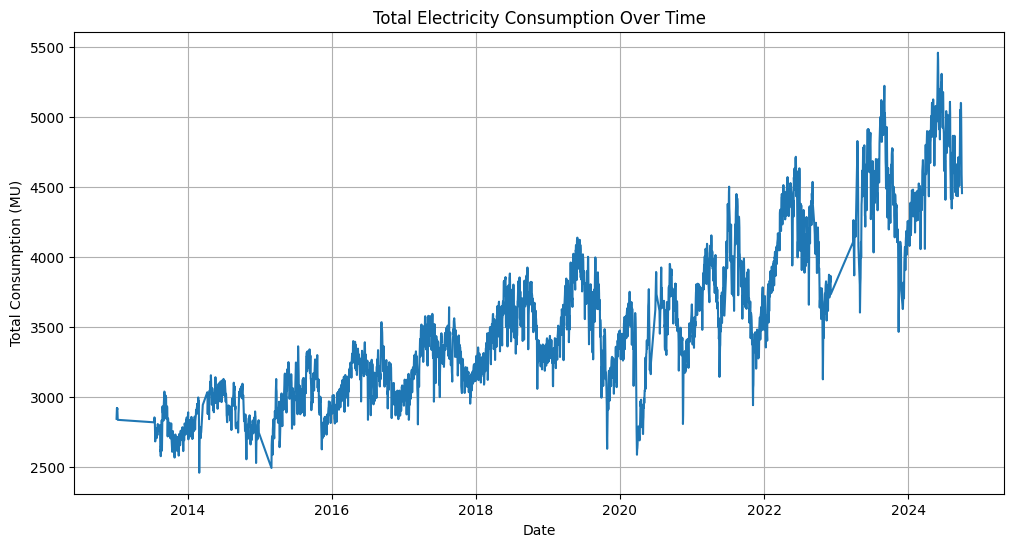

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql.functions import rand, round as spark_round


if 'raw_df' not in locals() or raw_df is None:
    raw_df = spark.read.csv("/content/Indias_Electricity_Consumption_Dataset.csv", header=True, inferSchema=True)
if 'weather_df' not in locals() or weather_df is None:
    weather_df = raw_df.select("Dates").withColumn("Temperature", spark_round((rand() * 20) + 15, 1))

pd_raw_df = raw_df.toPandas()
pd_raw_df['Dates'] = pd.to_datetime(pd_raw_df['Dates'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='Dates', y='Total Consumption', data=pd_raw_df)
plt.title('Total Electricity Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Total Consumption (MU)')
plt.grid(True)
plt.show()

/tmp/ipykernel_1970/1319761312.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Total_Consumption', data=state_total_consumption, palette='viridis')


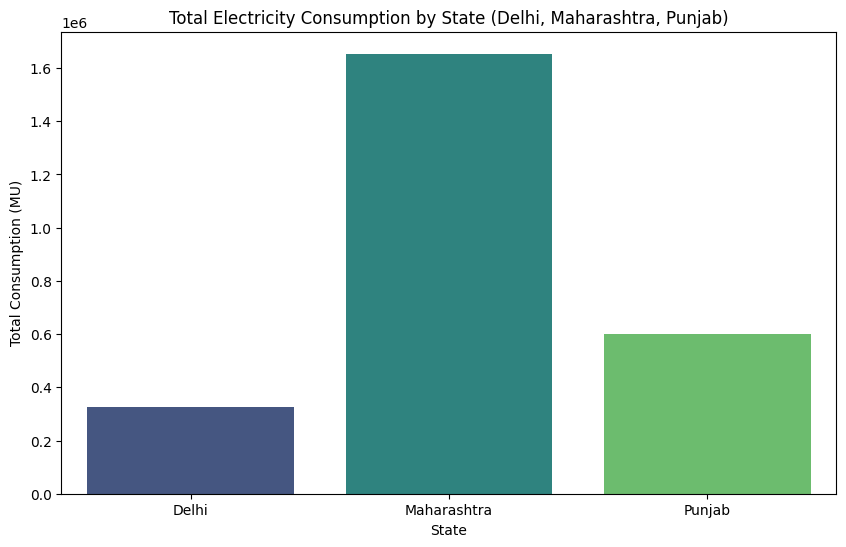

In [11]:
state_cols = ['Delhi', 'Maharashtra', 'Punjab']
state_total_consumption = pd_raw_df[state_cols].sum().reset_index()
state_total_consumption.columns = ['State', 'Total_Consumption']

plt.figure(figsize=(10, 6))
sns.barplot(x='State', y='Total_Consumption', data=state_total_consumption, palette='viridis')
plt.title('Total Electricity Consumption by State (Delhi, Maharashtra, Punjab)')
plt.xlabel('State')
plt.ylabel('Total Consumption (MU)')
plt.show()

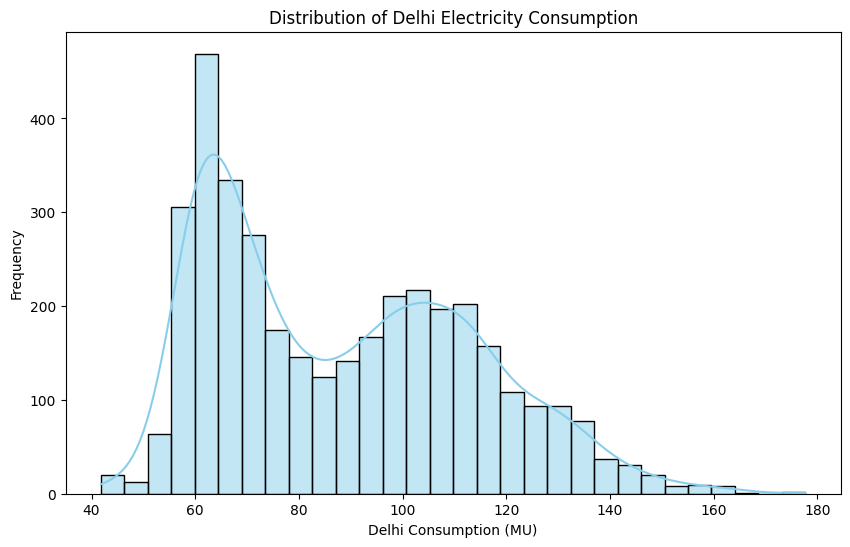

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(pd_raw_df['Delhi'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Delhi Electricity Consumption')
plt.xlabel('Delhi Consumption (MU)')
plt.ylabel('Frequency')
plt.show()

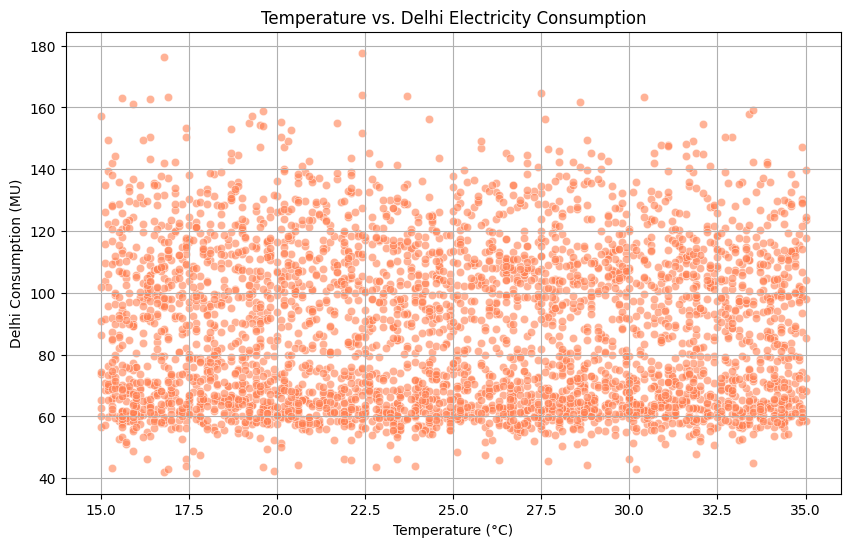

In [13]:
ml_dataset_for_plot = raw_df.select("Dates", "Delhi").join(weather_df, on="Dates").select("Temperature", "Delhi").dropna()
pd_ml_dataset = ml_dataset_for_plot.toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Delhi', data=pd_ml_dataset, alpha=0.6, color='coral')
plt.title('Temperature vs. Delhi Electricity Consumption')
plt.xlabel('Temperature (°C)')
plt.ylabel('Delhi Consumption (MU)')
plt.grid(True)
plt.show()

In [14]:
raw_df.createOrReplaceTempView("state_grid")

print("Average Monthly Consumption for Delhi:")
spark.sql("""
    SELECT month(to_date(Dates, 'dd/MM/yyyy')) AS month_of_year,
           AVG(Delhi) AS avg_monthly_demand
    FROM state_grid
    GROUP BY month_of_year
    ORDER BY month_of_year
""").show(5)

print("Total Electricity Usage for Top States (Regions):")
spark.sql("""
    SELECT
        SUM(Maharashtra) AS Total_Maharashtra,
        SUM(Delhi) AS Total_Delhi,
        SUM(Punjab) AS Total_Punjab
    FROM state_grid
""").show()

print("Peak Demand Periods:")
spark.sql("""
    SELECT Dates,
           (Maharashtra + Delhi + Punjab) AS total_demand
    FROM state_grid
    ORDER BY total_demand DESC
    LIMIT 5
""").show()

print("Yearly Consumption Report (Delhi):")
spark.sql("""
    SELECT year(to_date(Dates, 'dd/MM/yyyy')) AS year,
           SUM(Delhi) AS yearly_total_demand
    FROM state_grid
    GROUP BY year
    ORDER BY year
""").show(5)

Average Monthly Consumption for Delhi:
+-------------+------------------+
|month_of_year|avg_monthly_demand|
+-------------+------------------+
|            1| 70.60640569395021|
|            2| 64.36245059288537|
|            3| 63.71192982456136|
|            4| 83.66688524590155|
|            5|101.72269938650308|
+-------------+------------------+
only showing top 5 rows
Total Electricity Usage for Top States (Regions):
+------------------+-----------------+-----------------+
| Total_Maharashtra|      Total_Delhi|     Total_Punjab|
+------------------+-----------------+-----------------+
|1653762.1000000017|327112.2999999996|599283.8999999999|
+------------------+-----------------+-----------------+

Peak Demand Periods:
+----------+------------+
|     Dates|total_demand|
+----------+------------+
|2023-06-21|      1101.6|
|2023-06-22|      1097.4|
|2023-06-23|      1096.5|
|2024-05-31|      1080.1|
|2024-05-30|      1077.6|
+----------+------------+

Yearly Consumption Report (Del

In [15]:
def run_etl_pipeline(input_csv, output_dir):
    print("Starting ETL Pipeline...")

    raw_data = spark.read.csv(input_csv, header=True, inferSchema=True)

    clean_data = raw_data.dropna(subset=["Dates"])

    smart_meter_data = clean_data.select("Dates", "Delhi", "Maharashtra", "Punjab")

    weather_data = clean_data.select("Dates").withColumn("Temperature", spark_round((rand() * 20) + 15, 1))

    smart_meter_data.write.mode("overwrite").parquet(f"{output_dir}/smart_meter_db")
    weather_data.write.mode("overwrite").parquet(f"{output_dir}/weather_db")

    print(f"ETL Pipeline completed! Clean data saved to {output_dir}")

run_etl_pipeline("Indias_Electricity_Consumption_Dataset.csv", "/content/processed_state_data")

Starting ETL Pipeline...
ETL Pipeline completed! Clean data saved to /content/processed_state_data


In [16]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

ml_dataset = raw_df.select("Dates", "Delhi").join(weather_df, on="Dates")

ml_dataset = ml_dataset.select("Temperature", "Delhi").dropna()

assembler = VectorAssembler(inputCols=["Temperature"], outputCol="features")
final_ml_data = assembler.transform(ml_dataset)

train_data, test_data = final_ml_data.randomSplit([0.8, 0.2], seed=42)

lr = LinearRegression(featuresCol="features", labelCol="Delhi")
model = lr.fit(train_data)

predictions = model.transform(test_data)

evaluator = RegressionEvaluator(labelCol="Delhi", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

print("Machine Learning Model Trained Successfully!")
print(f"Root Mean Squared Error (RMSE) on test data: {rmse}")

predictions.select("Temperature", "Delhi", "prediction").show(5)

Machine Learning Model Trained Successfully!
Root Mean Squared Error (RMSE) on test data: 25.53213774321343
+-----------+-----+-----------------+
|Temperature|Delhi|       prediction|
+-----------+-----+-----------------+
|       15.0| 62.8|88.85220765687531|
|       15.0| 86.4|88.85220765687531|
|       15.0|102.0|88.85220765687531|
|       15.1| 91.7|88.84677948569089|
|       15.2| 59.8|88.84135131450647|
+-----------+-----+-----------------+
only showing top 5 rows


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from pyspark.sql.functions import lit
from pyspark.sql.types import DoubleType

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [18]:
train_pd = train_data.toPandas()
test_pd = test_data.toPandas()

X_train_keras = np.array([f[0] for f in train_pd['features']]).reshape(-1, 1)
y_train_keras = train_pd['Delhi'].values

X_test_keras = np.array([f[0] for f in test_pd['features']]).reshape(-1, 1)

print(f"Keras X_train shape: {X_train_keras.shape}, y_train shape: {y_train_keras.shape}")
print(f"Keras X_test shape: {X_test_keras.shape}")

Keras X_train shape: (3020, 1), y_train shape: (3020,)
Keras X_test shape: (687, 1)


In [19]:
model_ann = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_keras.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model_ann.compile(optimizer='adam', loss='mse')

model_ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
print("Training Keras ANN model...")
history = model_ann.fit(
    X_train_keras,
    y_train_keras,
    epochs=50,
    batch_size=32,
    verbose=0,
    validation_split=0.2
)
print("Keras ANN model trained successfully!")

loss = model_ann.evaluate(X_test_keras, test_pd['Delhi'].values, verbose=0)
print(f"Keras Test Loss (MSE): {loss:.4f}")

Training Keras ANN model...
Keras ANN model trained successfully!
Keras Test Loss (MSE): 832.8969


In [21]:
k_predictions_raw = model_ann.predict(X_test_keras).flatten()
k_predictions_pd = test_pd.copy()
k_predictions_pd['prediction'] = k_predictions_raw
k_predictions_pd['id'] = 1
k_predictions_spark = spark.createDataFrame(k_predictions_pd[['id', 'prediction']])
ann_predictions = test_data.withColumn('prediction', lit(0.0).cast(DoubleType()))
predictions_list = test_data.rdd.map(lambda row: row['features'][0]).collect()
predicted_values = model_ann.predict(np.array(predictions_list).reshape(-1, 1)).flatten()
ann_pred_df = test_data.toPandas()
ann_pred_df['prediction'] = predicted_values
ann_predictions_spark = spark.createDataFrame(ann_pred_df)
ann_evaluator = RegressionEvaluator(labelCol="Delhi", predictionCol="prediction", metricName="rmse")
ann_rmse = ann_evaluator.evaluate(ann_predictions_spark)

print("\nArtificial Neural Network (ANN) Model Trained Successfully!")
print(f"Root Mean Squared Error (RMSE) on test data (ANN): {ann_rmse}")

ann_predictions_spark.select("Temperature", "Delhi", "prediction").show(5)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Artificial Neural Network (ANN) Model Trained Successfully!
Root Mean Squared Error (RMSE) on test data (ANN): 28.859951930730624
+-----------+-----+-----------------+
|Temperature|Delhi|       prediction|
+-----------+-----+-----------------+
|       15.0| 62.8|67.26105499267578|
|       15.0| 86.4|67.26105499267578|
|       15.0|102.0|67.26105499267578|
|       15.1| 91.7|67.47274017333984|
|       15.2| 59.8| 67.6844253540039|
+-----------+-----+-----------------+
only showing top 5 rows
